## Step 1: Install and Import Libraries

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn nltk -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print('All libraries imported!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported!
TensorFlow version: 2.20.0


## Task 1: Dataset Understanding

In [2]:
# Upload customer_support_text_classification.csv to Colab first
df = pd.read_csv('customer_support_text_classification.csv')

print('=== Dataset Overview ===')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')

print('\n=== First 3 Rows ===')
display(df.head(3))

print('\n=== Target Label Distribution ===')
print(df['sentiment_label'].value_counts())

print('\n=== Sample Text Records ===')
for i, row in df.sample(3, random_state=42).iterrows():
    print(f'  [{row["sentiment_label"]}] {row["customer_message"][:100]}...')

print(f'\n=== Average Message Length ===')
if 'word_count' in df.columns:
    print(f'  Average word count: {df["word_count"].mean():.1f} words')
    print(f'  Min: {df["word_count"].min()} | Max: {df["word_count"].max()}')
else:
    df['word_count'] = df['customer_message'].apply(lambda x: len(str(x).split()))
    print(f'  Average word count: {df["word_count"].mean():.1f} words')

=== Dataset Overview ===
Shape: 1500 rows × 6 columns

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

=== First 3 Rows ===


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0



=== Target Label Distribution ===
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

=== Sample Text Records ===
  [neutral] I am checking if there is any scheduled maintenance today....
  [positive] The app experience is smooth and reliable. I appreciate the quick response....
  [neutral] Can you confirm whether my ticket has been assigned?...

=== Average Message Length ===
  Average word count: 12.7 words
  Min: 7 | Max: 26


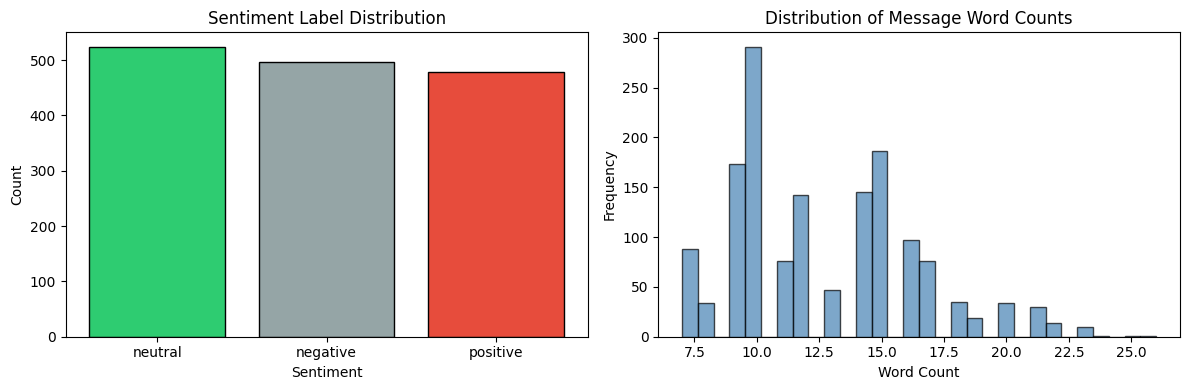

In [3]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sentiment_counts = df['sentiment_label'].value_counts()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Sentiment Label Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Word count distribution
axes[1].hist(df['word_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Message Word Counts')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=100)
plt.show()

## Task 2: Text Preprocessing

In [4]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    """Clean a text string step by step."""
    text = str(text).lower()                        # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # 2. Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)            # 3. Remove special characters & numbers
    text = re.sub(r'\s+', ' ', text).strip()        # 4. Remove extra spaces
    tokens = text.split()                            # 5. Tokenize
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 2]  # 6. Remove stopwords
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['customer_message'].apply(clean_text)

# Show before/after
print('=== Text Cleaning Comparison (3 examples) ===')
for i in range(3):
    print(f'\nOriginal: {df["customer_message"].iloc[i][:120]}')
    print(f'Cleaned:  {df["clean_text"].iloc[i][:120]}')

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment_label'])
print(f'\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

=== Text Cleaning Comparison (3 examples) ===

Original: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Cleaned:  need information payment process ticket number please respond soon possible

Original: I need information about the payment process.
Cleaned:  need information payment process

Original: The refund process was fast and convenient. I appreciate the quick response.
Cleaned:  refund process fast convenient appreciate quick response

Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


## Task 3: Text Vectorization

In [5]:
# --- Why text needs to be vectorized ---
print('=== WHY TEXT VECTORIZATION IS NEEDED ===')
print('Machine learning models only understand numbers.')
print('Text must be converted to numerical vectors first.')
print('We use TF-IDF here: Term Frequency × Inverse Document Frequency')
print('  - TF: How often a word appears in a message')
print('  - IDF: How rare the word is across all messages')
print('  - Common words (like "the") get LOW scores')
print('  - Unique, informative words get HIGH scores')

# Train-test split first
X_text = df['clean_text'].values
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f'\nTF-IDF Matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF Matrix shape (test):  {X_test_tfidf.shape}')
print(f'Number of unique features: {X_train_tfidf.shape[1]}')

=== WHY TEXT VECTORIZATION IS NEEDED ===
Machine learning models only understand numbers.
Text must be converted to numerical vectors first.
We use TF-IDF here: Term Frequency × Inverse Document Frequency
  - TF: How often a word appears in a message
  - IDF: How rare the word is across all messages
  - Common words (like "the") get LOW scores
  - Unique, informative words get HIGH scores

TF-IDF Matrix shape (train): (1200, 427)
TF-IDF Matrix shape (test):  (300, 427)
Number of unique features: 427


## Task 4: Baseline Model — Logistic Regression with TF-IDF

=== Logistic Regression (Baseline) Results ===
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



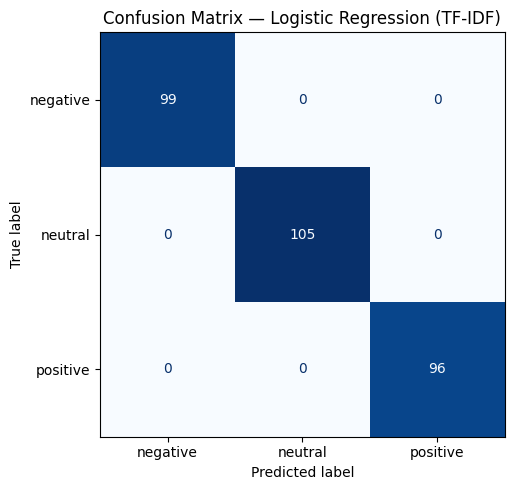

Sample predictions saved to sample_predictions.txt


In [6]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print('=== Logistic Regression (Baseline) Results ===')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression (TF-IDF)')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=100)
plt.show()

# Save sample predictions
with open('sample_predictions.txt', 'w') as f:
    f.write('Sample Predictions — Logistic Regression Baseline\n')
    f.write('='*55 + '\n\n')
    for i in range(10):
        true = le.classes_[y_test[i]]
        pred = le.classes_[y_pred_lr[i]]
        status = '✓' if true == pred else '✗'
        f.write(f'{status} True: {true:<10} | Pred: {pred}\n')
        f.write(f'  Text: {X_test_text[i][:80]}...\n\n')

print('Sample predictions saved to sample_predictions.txt')

In [7]:
# Also try Naive Bayes for comparison
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print('=== Naive Bayes (Bag of Words) Results ===')
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

# Save model evaluation results
from sklearn.metrics import accuracy_score, f1_score
eval_df = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'Naive Bayes (TF-IDF)'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_nb), 4)
    ],
    'F1 Score (weighted)': [
        round(f1_score(y_test, y_pred_lr, average='weighted'), 4),
        round(f1_score(y_test, y_pred_nb, average='weighted'), 4)
    ]
})
display(eval_df)
eval_df.to_csv('model_evaluation.csv', index=False)
print('Model evaluation saved to model_evaluation.csv')

=== Naive Bayes (Bag of Words) Results ===
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



,Model,Accuracy,F1 Score (weighted)
0,Logistic Regression (TF-IDF),1.0,1.0
1,Naive Bayes (TF-IDF),1.0,1.0


Model evaluation saved to model_evaluation.csv


## Task 5: LSTM Sequence Model

In [8]:
# Tokenize text for LSTM (token IDs instead of TF-IDF)
VOCAB_SIZE = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences to equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

NUM_CLASSES = len(le.classes_)

print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Padded sequence shape (train): {X_train_pad.shape}')
print(f'Padded sequence shape (test):  {X_test_pad.shape}')
print(f'Number of classes: {NUM_CLASSES}')

Vocabulary size: 147
Padded sequence shape (train): (1200, 100)
Padded sequence shape (test):  (300, 100)
Number of classes: 3


In [9]:
# Build LSTM Model
lstm_model = Sequential(name='SentimentLSTM')
lstm_model.add(Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN, name='embedding'))
lstm_model.add(Bidirectional(LSTM(64, return_sequences=False), name='bidirectional_lstm'))
lstm_model.add(Dropout(0.3, name='dropout'))
lstm_model.add(Dense(32, activation='relu', name='dense'))
lstm_model.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

print('\n=== LSTM Architecture Explanation ===')
print('1. Embedding Layer    : Converts word IDs to 64-dim dense vectors')
print('2. Bidirectional LSTM : Reads sequence forwards AND backwards')
print('3. Dropout            : Prevents overfitting by randomly turning off neurons')
print('4. Dense(32, ReLU)    : Learns abstract features from LSTM output')
print('5. Dense(3, Softmax)  : Outputs probability for each of 3 sentiment classes')

Model: "SentimentLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


=== LSTM Architecture Explanation ===
1. Embedding Layer    : Converts word IDs to 64-dim dense vectors
2. Bidirectional LSTM : Reads sequence forwards AND backwards
3. Dropout            : Prevents overfitting by randomly turning off neurons
4. Dense(32, ReLU)    : Learns abstract features from LSTM output
5. Dense(3, Softmax)  : Outputs probability for each of 3 sentiment classes


In [10]:
# Train LSTM
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

# Evaluate
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
print(f'\nLSTM Test Accuracy: {lstm_acc:.4f} ({lstm_acc*100:.2f}%)')

# Update evaluation table
eval_df.loc[2] = ['Bidirectional LSTM', round(lstm_acc, 4),
                  round(f1_score(y_test, np.argmax(lstm_model.predict(X_test_pad, verbose=0), axis=1),
                                average='weighted'), 4)]
display(eval_df)
eval_df.to_csv('model_evaluation.csv', index=False)
print('Updated evaluation table saved.')

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 484ms/step - accuracy: 0.4706 - loss: 1.0609 - val_accuracy: 0.8778 - val_loss: 0.9786
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.9010 - loss: 0.7839 - val_accuracy: 1.0000 - val_loss: 0.4058
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.9657 - loss: 0.3128 - val_accuracy: 1.0000 - val_loss: 0.1032
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step - accuracy: 0.9990 - loss: 0.0521 - val_accuracy: 1.0000 - val_loss: 0.0136
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1

,Model,Accuracy,F1 Score (weighted)
0,Logistic Regression (TF-IDF),1.0,1.0
1,Naive Bayes (TF-IDF),1.0,1.0
2,Bidirectional LSTM,1.0,1.0


Updated evaluation table saved.


## Task 6: Attention and Transformer Reflection

### Why RNNs Struggle with Long-Term Dependencies
RNNs process text **one word at a time**, passing information through a hidden state. As sequences get longer, information from early words gets diluted — the gradient signal becomes very small during backpropagation. This is called the **vanishing gradient problem**. By the end of a long sentence, the model has "forgotten" what was at the beginning.

### How LSTMs Help with Memory
LSTMs introduce three **gates**:
- **Forget Gate:** Decides what to remove from memory
- **Input Gate:** Decides what new info to store
- **Output Gate:** Decides what to output from memory

These gates allow the network to selectively retain important information over long sequences, solving the vanishing gradient problem for moderate sequence lengths.

### What Attention Solves
Even LSTMs struggle with very long sequences because they still process one word at a time. **Attention mechanisms** allow the model to look at ALL words simultaneously and assign different importance ("attention weights") to each word for a given prediction. This is like highlighting the most important words in a sentence instead of reading it linearly.

### Why Transformers Are Important in Modern NLP and GenAI
Transformers use **self-attention** — every word attends to every other word in parallel (not sequential). This means:
1. **Parallelization:** Training is much faster (GPU-friendly)
2. **Long-range dependencies:** No information loss over distance
3. **Scalability:** Can be scaled to billions of parameters
4. **Versatility:** Same architecture works for translation, summarization, Q&A, code generation

GPT (ChatGPT), BERT, T5, and all modern LLMs are built on the transformer architecture. Transformers have completely replaced RNNs in state-of-the-art NLP.